In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import linear_model
import sklearn.metrics as sm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# 1. بارگذاری داده‌ها
df = pd.read_csv("co2.csv")

In [3]:
# 2. انتخاب ویژگی‌ها (X) و متغیر هدف (y)
# فقط ستون out1 را حذف می‌کنیم تا سه ستون دیگر باقی بمانند
x = df.drop("out1", axis=1) 
y = df["out1"]

In [4]:

# 3. نمایش اطلاعات داده‌ها (اختیاری)
print("ستون‌های ورودی:", x.columns.tolist())
print(df.describe())

ستون‌های ورودی: ['engine', 'cylandr', 'fuelcomb']
           engine     cylandr    fuelcomb        out1
count  500.000000  500.000000  500.000000  500.000000
mean     3.600400    6.132000   12.476600  268.026000
std      1.478191    1.832291    3.943025   67.099673
min      1.000000    4.000000    4.800000  110.000000
25%      2.000000    4.000000    9.500000  217.000000
50%      3.600000    6.000000   11.650000  260.000000
75%      5.000000    8.000000   14.800000  317.000000
max      6.800000   12.000000   25.800000  488.000000


In [5]:

# 4._split داده‌ها به آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:

# 5. ساخت و آموزش مدل
model = linear_model.LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [7]:

# 6. پیش‌بینی روی داده‌های تست
y_pred = model.predict(X_test)

In [8]:
y_pred

array([334.19965282, 388.5502439 , 353.67574927, 210.25238283,
       299.24456216, 174.12167596, 266.79857423, 314.13574828,
       212.05500385, 344.34917742, 208.01870491, 333.572648  ,
       214.28868177, 203.12029218, 341.76280037, 359.82817164,
       181.54767066, 228.25783988, 205.04046768, 210.56588524,
       189.87497587, 252.80869862, 213.97517936, 198.96643875,
       197.90837703, 342.84046044, 187.50414511, 332.41663016,
       243.149026  , 187.95480036, 345.4855969 , 187.21024106,
       374.1119513 , 346.97471551, 174.1020776 , 187.21024106,
       193.46061956, 381.10465083, 300.75439826, 295.83526804,
       309.23845468, 203.12029218, 244.61854626, 259.05907712,
       230.4915178 , 200.14205495, 198.65293634, 250.57502071,
       176.31615716, 204.60941079, 388.5502439 , 387.92547735,
       308.17927383, 191.52084569, 346.97471551, 293.60159012,
       200.57311185, 322.46305349, 207.2741456 , 200.88661426,
       177.08031482, 351.03061281, 325.402094  , 204.29

In [9]:
y_test

361    368
73     380
374    402
155    218
104    292
      ... 
347    386
86     221
75     437
438    344
15     338
Name: out1, Length: 100, dtype: int64

In [10]:
# 7. ارزیابی مدل
print("ضریب تعیین (R^2):", sm.r2_score(y_test, y_pred))
print("میانگین خطای مطلق (MAE):", sm.mean_absolute_error(y_test, y_pred))
print("ضرایب مدل (Coefficients):", model.coef_)
print("عرض از مبدا (Intercept):", model.intercept_)

ضریب تعیین (R^2): 0.8531035728037535
میانگین خطای مطلق (MAE): 22.40052754155982
ضرایب مدل (Coefficients): [10.38463357 11.0992536   7.44559306]
عرض از مبدا (Intercept): 70.19911379024472


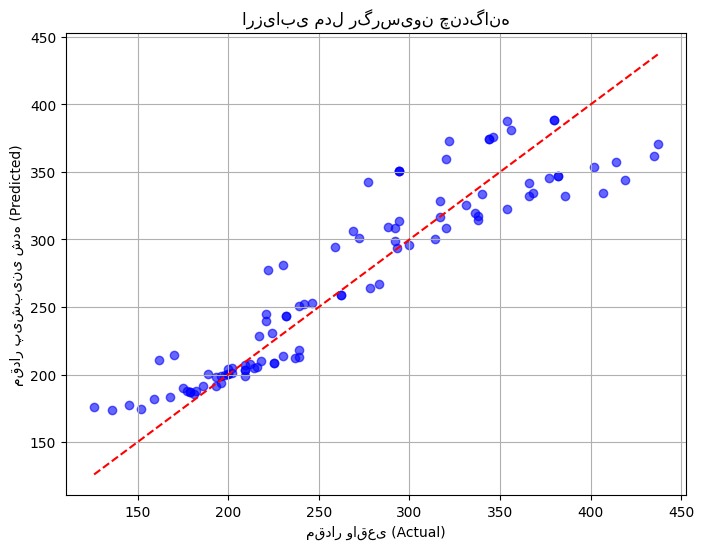

In [11]:
# 8. رسم نمودار (مقدار واقعی در برابر پیش‌بینی شده)
# چون ۳ ورودی داریم، نمی‌توانیم نمودار خطی ساده مثل قبل رسم کنیم.
# این نمودار نشان می‌دهد مدل چقدر خوب پیش‌بینی کرده است.
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # خط ایده‌آل
plt.xlabel("مقدار واقعی (Actual)")
plt.ylabel("مقدار پیش‌بینی شده (Predicted)")
plt.title("ارزیابی مدل رگرسیون چندگانه")
plt.grid(True)
plt.show()

In [12]:
# 9. پیش‌بینی برای داده جدید
# حالا باید برای هر ۳ پارامتر مقدار وارد کنید [engine, cylandr, fuelcomb]
# مثال: فرض کنید engine=3.6, cylandr=6, fuelcomb=12.0
new_data = np.array([[3.6, 6.0, 12.0]]) 
prediction = model.predict(new_data)

print(f"پیش‌بینی خروجی برای ورودی‌های {new_data[0]} برابر است با: {prediction[0]}")

پیش‌بینی خروجی برای ورودی‌های [ 3.6  6.  12. ] برابر است با: 263.52643295963117


c:\Users\USER\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
